# 准备数据

In [25]:
import sys
sys.path.append('/home/hyd/research/vnpy_hub')
sys.path.append('/home/hyd/research/vnpy_hub/vnpy')

In [26]:
# 过滤Alphalens的warning
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [27]:
# 加载模块
import polars as pl

from vnpy.trader.constant import Interval

from vnpy.alpha import AlphaLab

In [28]:
# 创建数据中心
lab: AlphaLab = AlphaLab("./lab/all_stocks")

In [29]:
# 设置任务参数
name = "300_mlp"
index_symbol: str = "000300.SSE"
start: str = "2017-01-01"
end: str = "2025-08-01"
interval: Interval = Interval.DAILY
extended_days: int = 100

In [30]:
# 加载所有成分股代码
component_symbols: list[str] = lab.load_component_symbols(index_symbol, start, end)

# 特征计算

In [31]:
# 加载模块
from datetime import datetime
from functools import partial

from vnpy.trader.constant import Interval

from vnpy.alpha.dataset import (
    AlphaDataset,
    process_drop_na,
    process_robust_zscore_norm,
    process_fill_na,
    process_cs_rank_norm,
    to_datetime
)
from vnpy.alpha.dataset.datasets.alpha_158 import Alpha158

In [32]:
# 加载成分股数据
df: pl.DataFrame = lab.load_bar_df(component_symbols, interval, start, end, extended_days)

In [33]:
# 设置数据时间段
train_period: tuple[str, str] = ("2017-01-01", "2021-12-31")
valid_period: tuple[str, str] = ("2022-01-01", "2023-12-31")
test_period: tuple[str, str] = ("2023-01-01", "2025-08-01")

In [34]:
# 创建数据集对象
dataset: AlphaDataset = Alpha158(
    df,
    train_period=train_period,
    valid_period=valid_period,
    test_period=test_period,
)

In [35]:
# 添加数据预处理器
fit_start_time: datetime = to_datetime(train_period[0])
fit_end_time: datetime = to_datetime(train_period[1])

dataset.add_processor("infer", partial(process_robust_zscore_norm, fit_start_time=fit_start_time, fit_end_time=fit_end_time))
dataset.add_processor("infer", partial(process_fill_na, fill_value=0, fill_label=False))

dataset.add_processor("learn", partial(process_drop_na, names=["label"]))
dataset.add_processor("learn", partial(process_cs_rank_norm, names=["label"]))

In [36]:
# 收集指数成分过滤器
filters: dict[str, list[str]] = lab.load_component_filters(index_symbol, start, end)

In [37]:
# 准备特征和标签数据
dataset.prepare_data(filters, max_workers=50)

2025-10-23 13:49:04 开始计算表达式因子特征


  1%|          | 1/159 [00:01<03:53,  1.48s/it]

Feature calculation kmid took: 0.032669782638549805 seconds | (close - open) / open


  1%|▏         | 2/159 [00:01<02:21,  1.11it/s]

Feature calculation klen took: 0.020540714263916016 seconds | (high - low) / open
Feature calculation kmid_2 took: 0.07326650619506836 seconds | (close - open) / (high - low + 1e-12)


...

Feature calculation imxd_30 took: 69.13850569725037 seconds | (ts_argmax(high, 30) - ts_argmin(low, 30)) / 30


2025-10-23 13:50:56 开始合并结果数据因子特征


0it [00:00, ?it/s]

2025-10-23 13:50:56 开始筛选成分股数据



100%|██████████| 591/591 [00:13<00:00, 43.35it/s]


Dropped 4.4% entries from factor data: 0.5% in forward returns computation and 3.9% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1.0,0.000000,0.776901,0.083379,0.097574,110194,10.071243
2.0,0.001660,0.831594,0.191210,0.141071,109355,9.994562
3.0,0.014077,0.874784,0.271417,0.168397,109188,9.979299
4.0,0.023992,0.904834,0.346050,0.184676,109316,9.990998
5.0,0.032521,0.925864,0.420706,0.192424,109492,10.007083
6.0,0.042553,0.941176,0.497206,0.192178,108898,9.952794
7.0,0.055556,0.958443,0.578589,0.183608,109136,9.974546
8.0,0.072465,0.977834,0.667460,0.165614,109355,9.994562
9.0,0.111807,0.997970,0.766495,0.136737,109179,9.978476


Returns Analysis


,1D,5D,10D
Ann. alpha,0.085,0.054,0.059
beta,-0.057,-0.034,-0.015
Mean Period Wise Return Top Quantile (bps),6.935,4.739,4.909
Mean Period Wise Return Bottom Quantile (bps),-6.743,-4.020,-3.318
Mean Period Wise Spread (bps),13.678,8.684,8.145


<Figure size 640x480 with 0 Axes>

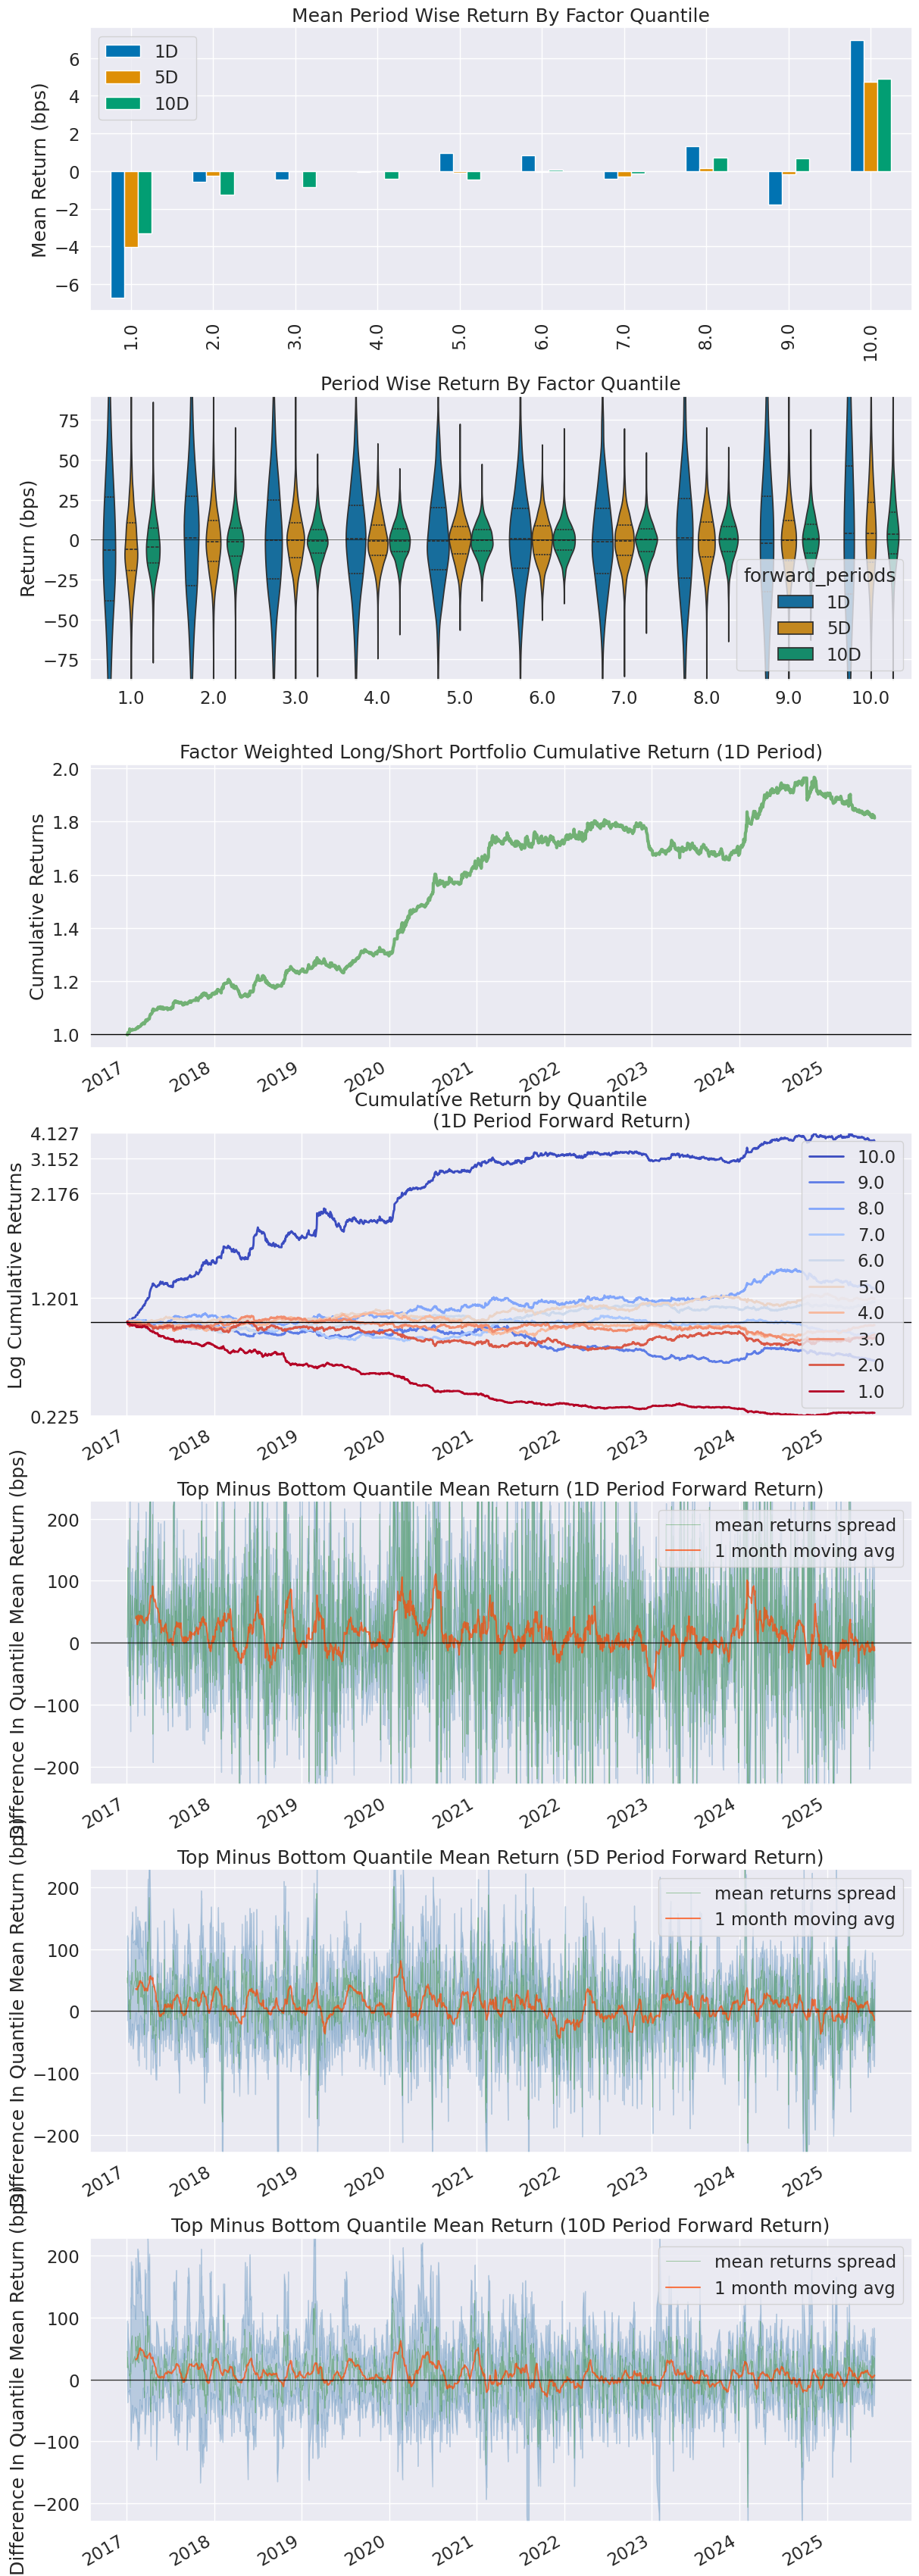

Information Analysis


,1D,5D,10D
IC Mean,-0.022,-0.001,0.009
IC Std.,0.159,0.145,0.142
Risk-Adjusted IC,-0.141,-0.004,0.064
t-stat(IC),NaN,NaN,NaN
p-value(IC),NaN,NaN,NaN
IC Skew,NaN,NaN,NaN
IC Kurtosis,NaN,NaN,NaN


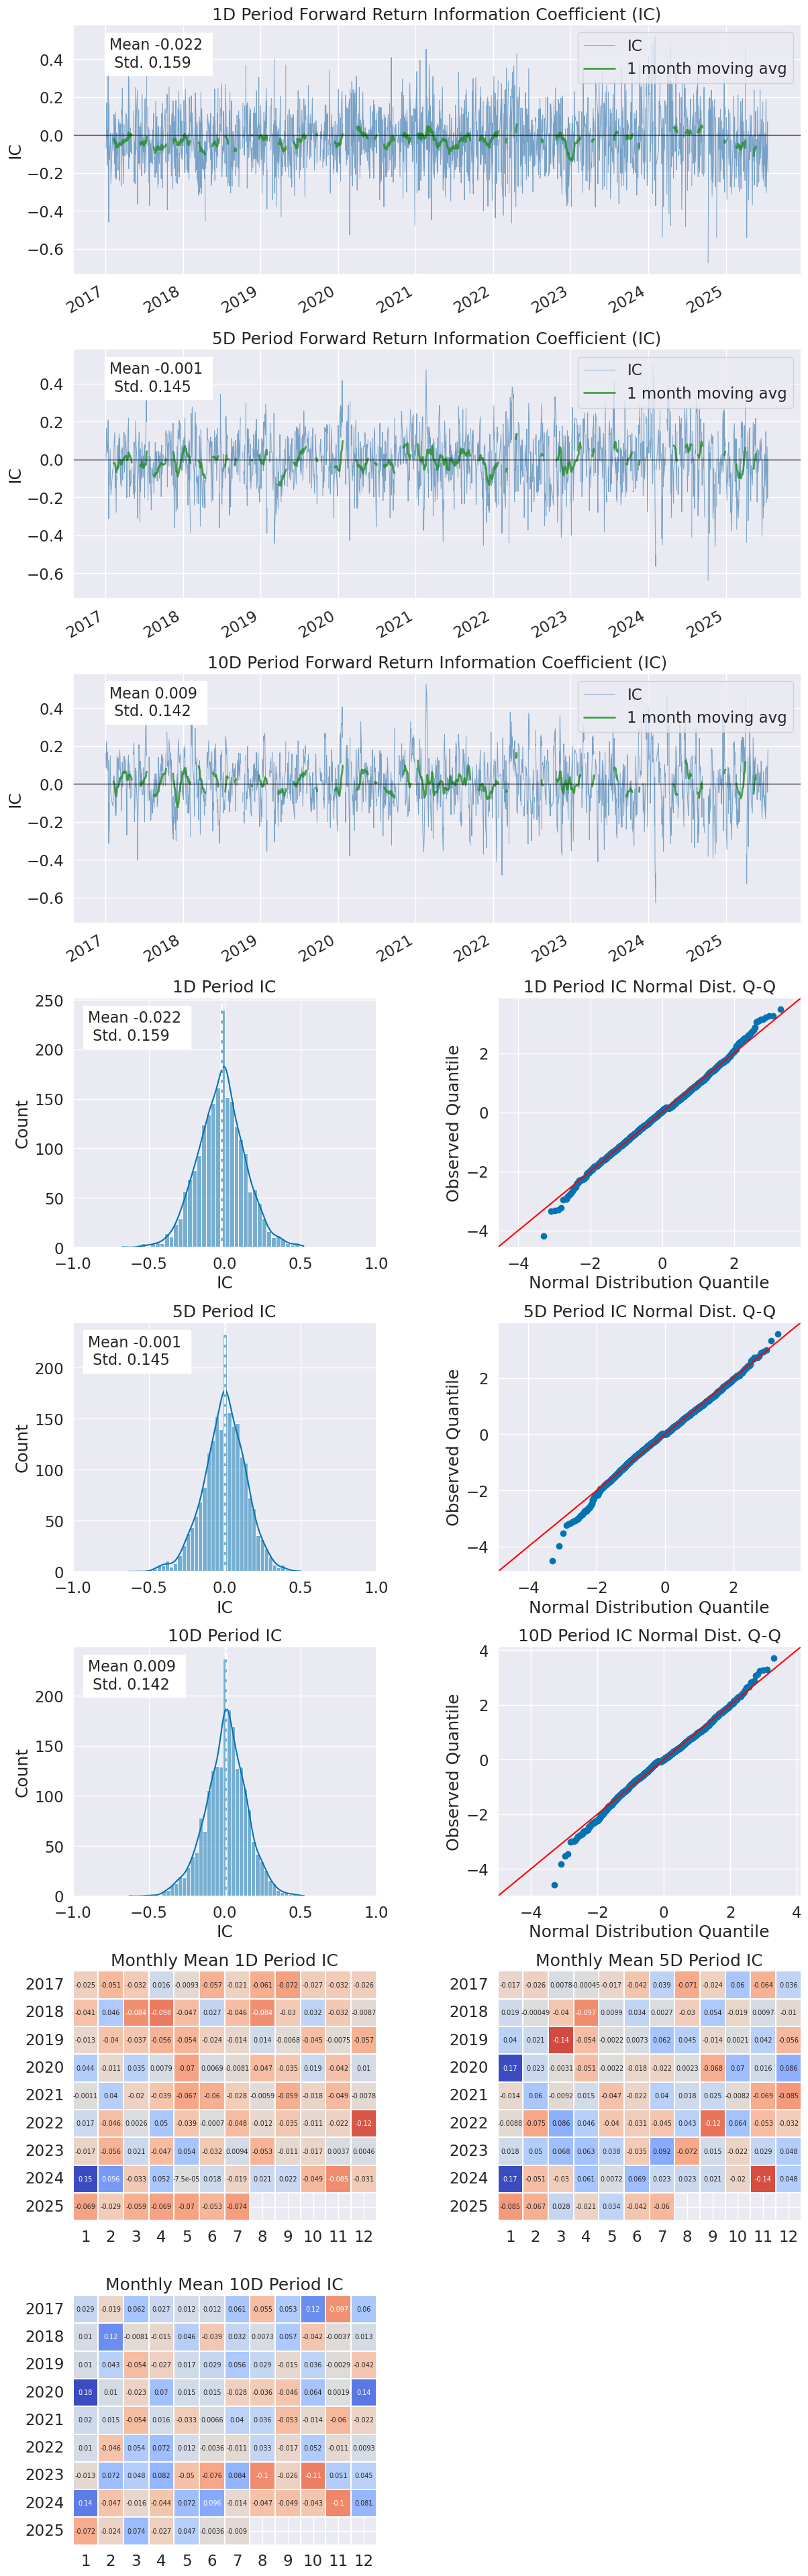

/home/hyd/miniforge3/envs/python311/lib/python3.11/site-packages/alphalens/utils.py:928: UserWarning:

Skipping return periods that aren't exact multiples of days.



Turnover Analysis


,1D,5D,10D
Quantile 1.0 Mean Turnover,0.591,0.797,0.801
Quantile 2.0 Mean Turnover,0.771,0.901,0.898
Quantile 3.0 Mean Turnover,0.824,0.898,0.897
Quantile 4.0 Mean Turnover,0.847,0.896,0.895
Quantile 5.0 Mean Turnover,0.857,0.896,0.895
Quantile 6.0 Mean Turnover,0.857,0.895,0.896
Quantile 7.0 Mean Turnover,0.852,0.899,0.898
Quantile 8.0 Mean Turnover,0.834,0.900,0.899
Quantile 9.0 Mean Turnover,0.788,0.898,0.895
Quantile 10.0 Mean Turnover,0.676,0.891,0.886


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.605,0.022,0.035


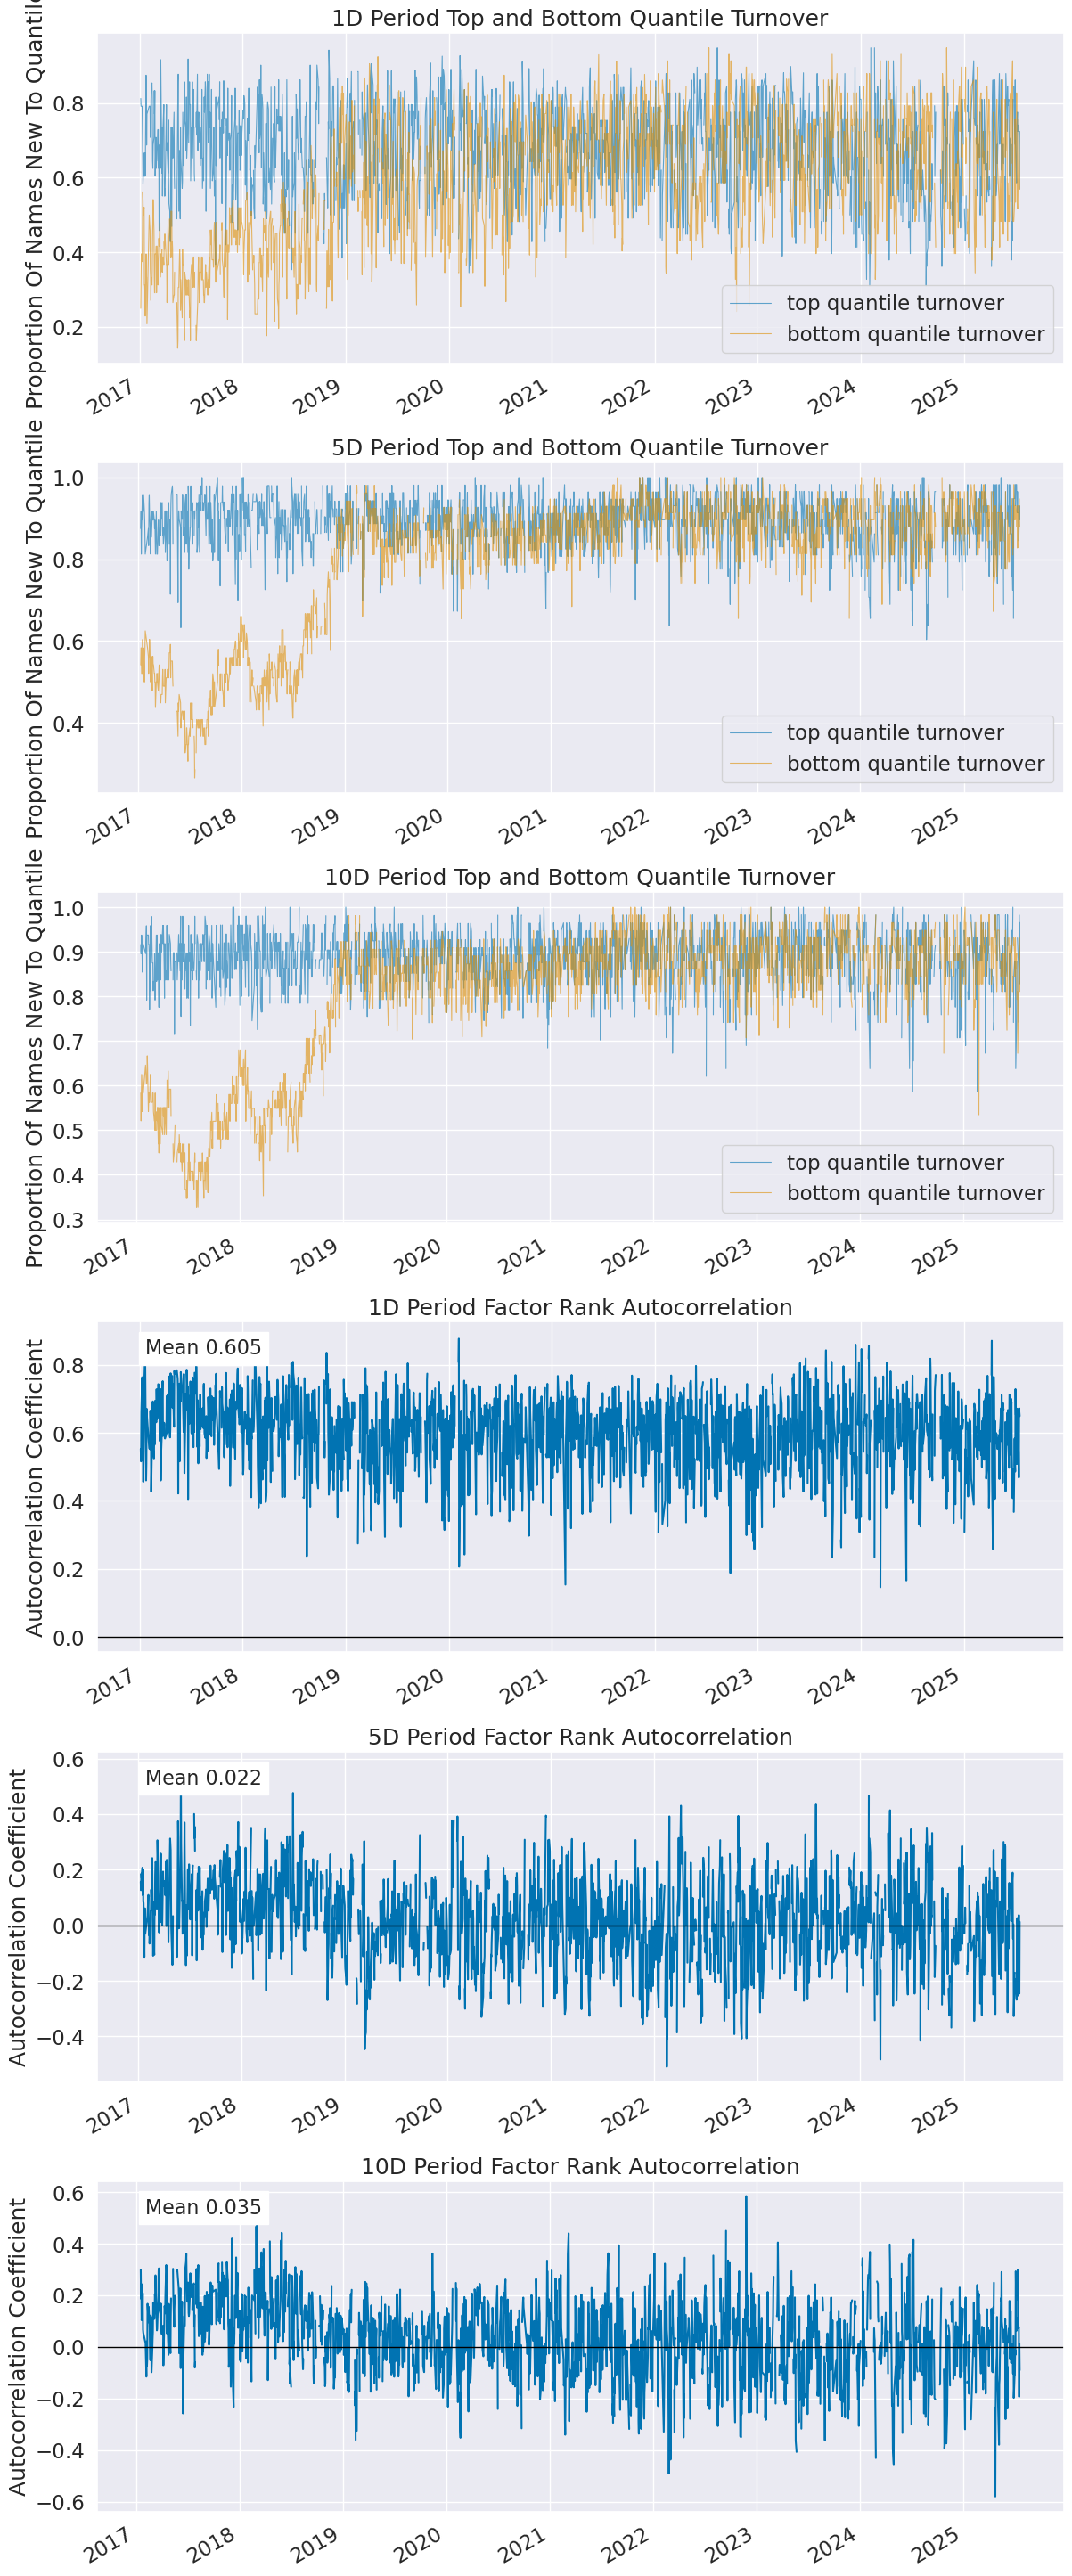

In [38]:
# 特征表现分析
dataset.show_feature_performance("rsv_5")

In [39]:
# 保存到文件缓存
lab.save_dataset(name, dataset, format='pkl')

# 模型训练

In [40]:
# 加载模块
import numpy as np

from vnpy.alpha import Segment, AlphaDataset, AlphaModel

from vnpy.alpha.model.models.mlp_model import MlpModel

In [41]:
# 从文件缓存加载
dataset: AlphaDataset = lab.load_dataset(name)

In [42]:
# 创建模型对象
kwargs = {
    "input_size": 158,
    "hidden_sizes": (256,),
    "lr": 0.002,
    "optimizer": "adam",
    "n_epochs": 8000,
    "batch_size": 8192,
    "weight_decay": 0.0002,
    "seed": 42,
    "device":"cpu" 
}

model: AlphaModel = MlpModel(**kwargs)

In [43]:
# 使用数据集训练模型
model.fit(dataset)

2025-10-23 13:51:38 [Step 20]: train_loss 1.243591, valid_loss 1.056312
2025-10-23 13:51:38 	验证集损失从 inf 降低到 1.056312


/home/hyd/miniforge3/envs/python311/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:1344: UserWarning:

The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.



2025-10-23 13:51:39 [Step 40]: train_loss 1.080522, valid_loss 1.020422
2025-10-23 13:51:39 	验证集损失从 1.056312 降低到 1.020422
2025-10-23 13:51:39 [Step 60]: train_loss 1.051584, valid_loss 1.015767
2025-10-23 13:51:39 	验证集损失从 1.020422 降低到 1.015767
2025-10-23 13:51:40 [Step 80]: train_loss 1.046453, valid_loss 1.008115
2025-10-23 13:51:40 	验证集损失从 1.015767 降低到 1.008115
2025-10-23 13:51:41 [Step 100]: train_loss 1.031382, valid_loss 1.008654
2025-10-23 13:51:42 [Step 120]: train_loss 1.027751, valid_loss 1.004360
2025-10-23 13:51:42 	验证集损失从 1.008115 降低到 1.004360
2025-10-23 13:51:43 [Step 140]: train_loss 1.020334, valid_loss 1.008060
2025-10-23 13:51:44 [Step 160]: train_loss 1.019472, valid_loss 1.005370
2025-10-23 13:51:44 [Step 180]: train_loss 1.018326, valid_loss 1.003804
2025-10-23 13:51:44 	验证集损失从 1.004360 降低到 1.003804
2025-10-23 13:51:45 [Step 200]: train_loss 1.006710, valid_loss 1.004592
2025-10-23 13:51:46 [Step 220]: train_loss 1.005623, valid_loss 1.001757
2025-10-23 13:51:46 	验证

In [44]:
# 查看模型细节
model.detail()

2025-10-23 13:52:50 输入特征维度: 158
2025-10-23 13:52:50 隐藏层大小: (256,)
2025-10-23 13:52:50 模型总参数量: 41,473
2025-10-23 13:52:50 训练设备: cpu
2025-10-23 13:52:50 当前学习率: 0.002
2025-10-23 13:52:50 批次大小: 8192


,Importance
Feature,
rank_5,0.002170
klow,0.001964
rsv_30,0.001540
cord_60,0.001458
min_60,0.001453
...,...
imax_20,0.000743
rank_60,0.000719
cntp_5,0.000718


In [45]:
# 保存模型
lab.save_model(name, model)

# 预测信号

In [46]:
model: AlphaModel = lab.load_model(name)

In [47]:
# 用模型在测试集上预测
pre: np.ndarray = model.predict(dataset, Segment.TEST)

# 加载测试集数据
df_t: pl.DataFrame = dataset.fetch_infer(Segment.TEST)

# 合并预测信号列
df_t = df_t.with_columns(pl.Series(pre).alias("signal"))

# 提取信号数据
signal: pl.DataFrame = df_t["datetime", "vt_symbol", "signal"]

Dropped 1.6% entries from factor data: 1.6% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.752409,-0.021375,-0.165708,0.072719,18450,10.0
2,-0.487322,0.016614,-0.088189,0.048943,18450,10.0
3,-0.400227,0.049412,-0.050351,0.045005,18450,10.0
4,-0.354966,0.074820,-0.020873,0.043036,18450,10.0
5,-0.323496,0.099792,0.005113,0.041510,18450,10.0
6,-0.274687,0.132742,0.030340,0.040182,18450,10.0
7,-0.231009,0.160569,0.056385,0.039340,18450,10.0
8,-0.199198,0.189949,0.085270,0.038219,18450,10.0
9,-0.151329,0.237800,0.121738,0.037993,18450,10.0


Returns Analysis


,1D,5D,10D
Ann. alpha,0.190,0.103,0.067
beta,-0.164,-0.170,-0.112
Mean Period Wise Return Top Quantile (bps),7.646,4.422,2.834
Mean Period Wise Return Bottom Quantile (bps),-9.982,-5.677,-3.826
Mean Period Wise Spread (bps),17.629,10.153,6.739


<Figure size 640x480 with 0 Axes>

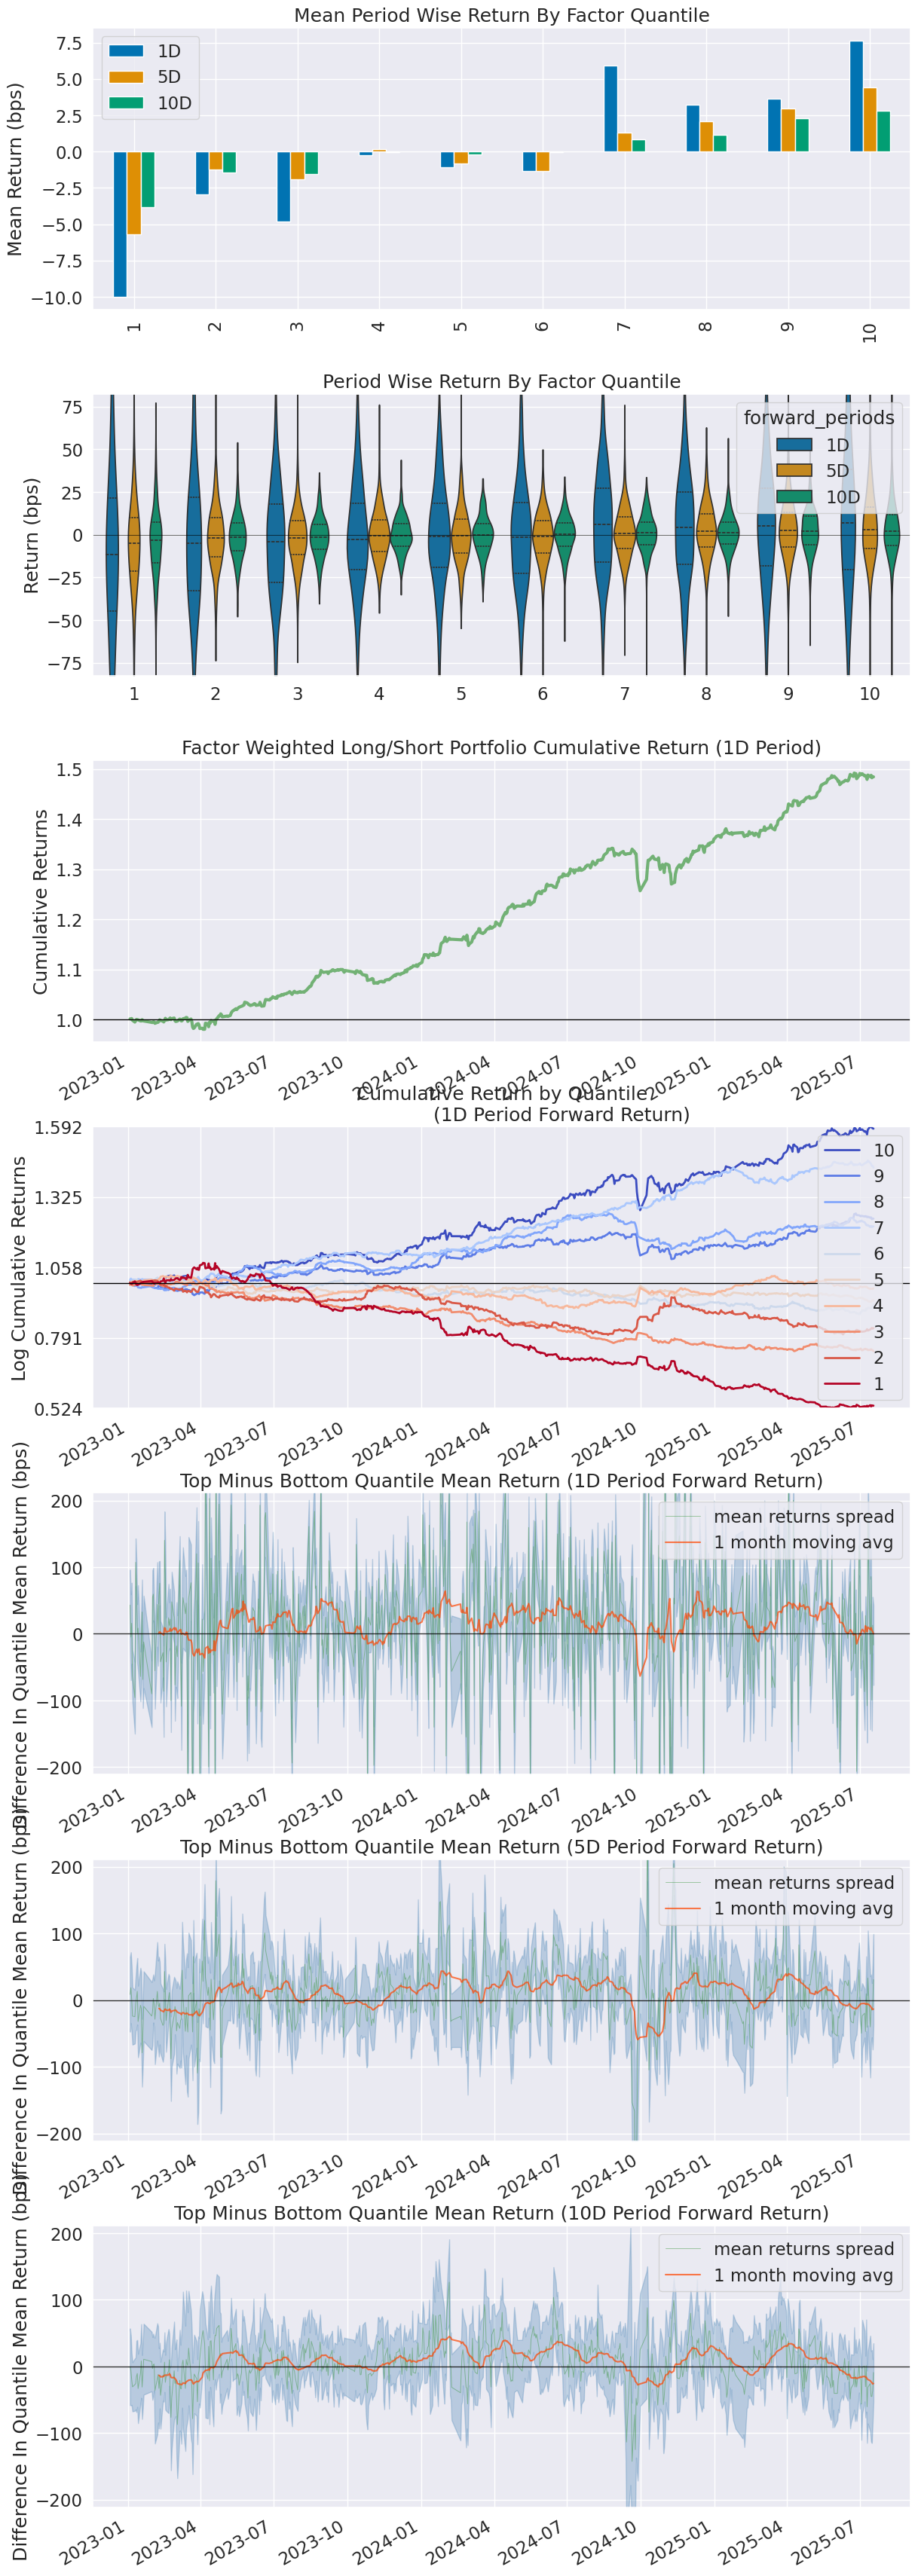

Information Analysis


,1D,5D,10D
IC Mean,0.046,0.054,0.046
IC Std.,0.136,0.131,0.133
Risk-Adjusted IC,0.338,0.409,0.345
t-stat(IC),8.389,10.154,8.560
p-value(IC),0.000,0.000,0.000
IC Skew,-0.092,0.251,0.253
IC Kurtosis,0.571,0.638,0.257


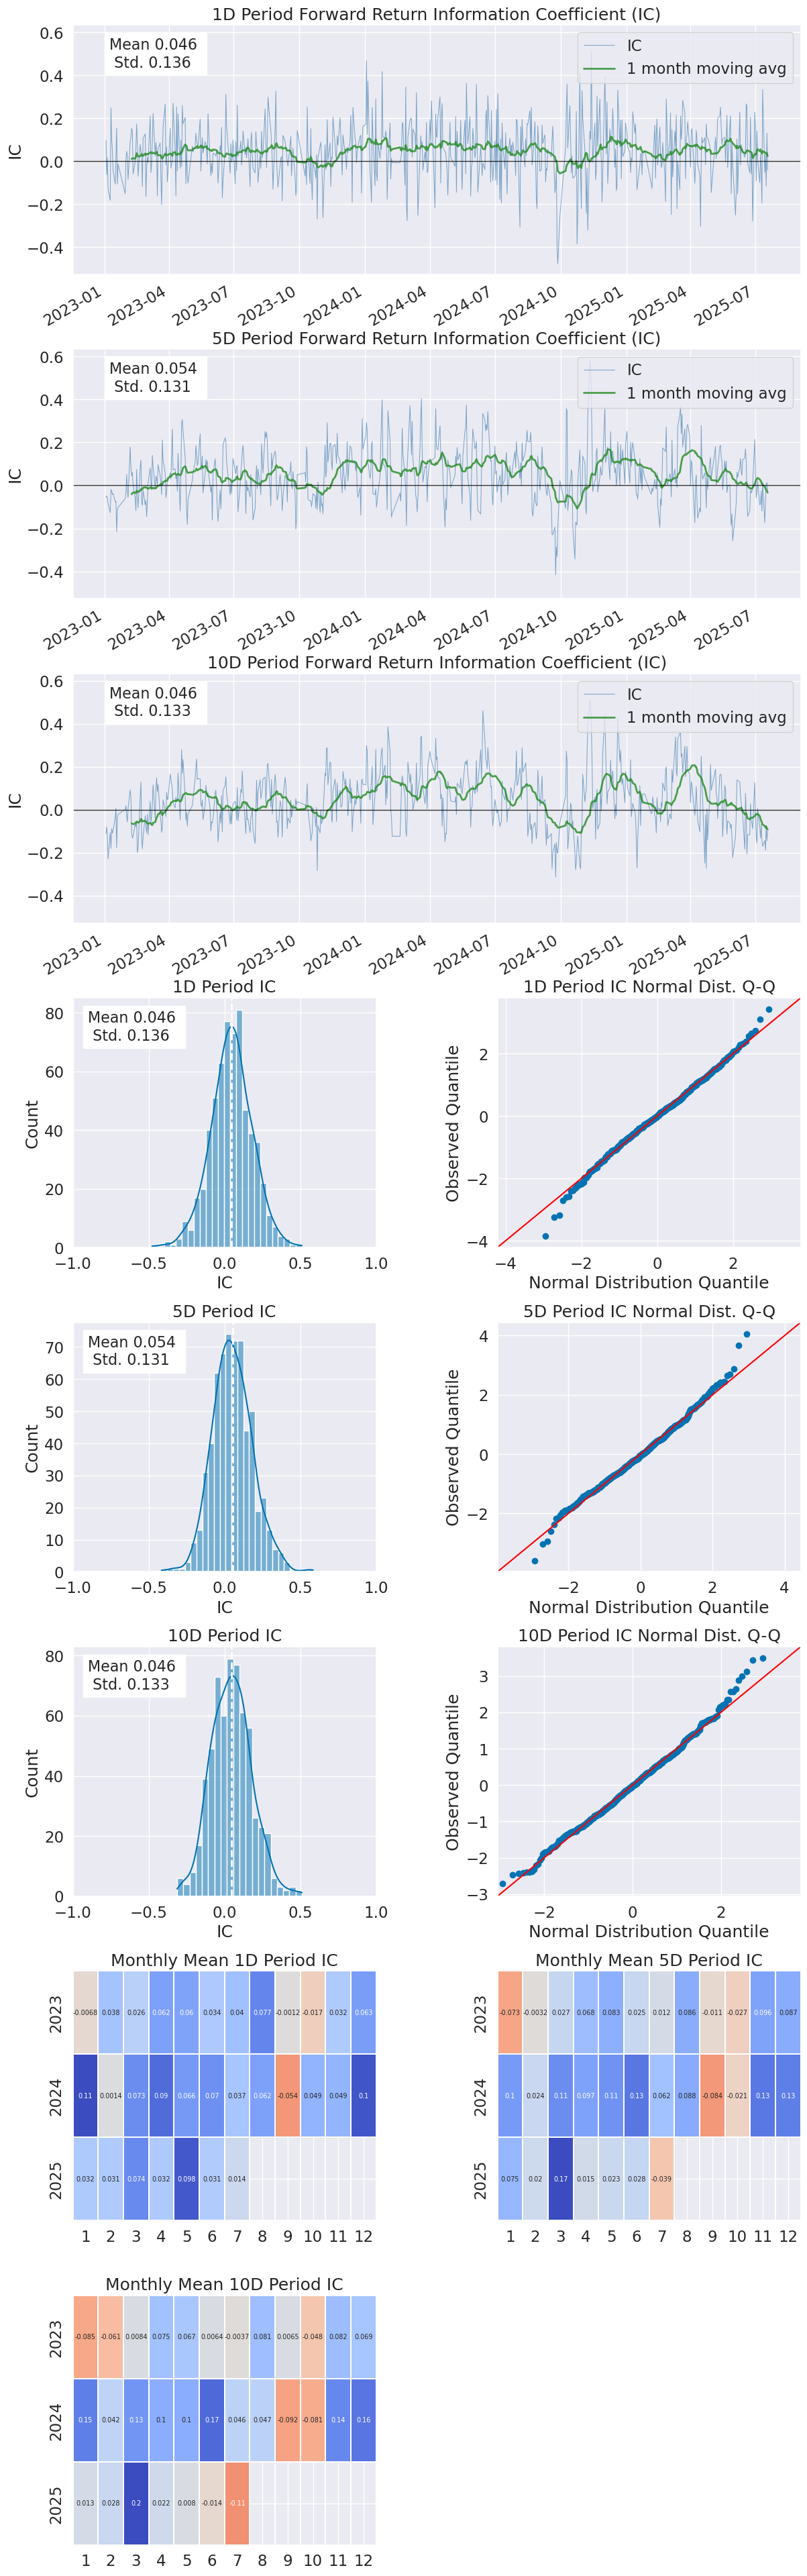

/home/hyd/miniforge3/envs/python311/lib/python3.11/site-packages/alphalens/utils.py:928: UserWarning:

Skipping return periods that aren't exact multiples of days.



Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.572,0.802,0.816
Quantile 2 Mean Turnover,0.797,0.867,0.882
Quantile 3 Mean Turnover,0.837,0.883,0.890
Quantile 4 Mean Turnover,0.856,0.890,0.891
Quantile 5 Mean Turnover,0.862,0.891,0.898
Quantile 6 Mean Turnover,0.863,0.892,0.895
Quantile 7 Mean Turnover,0.860,0.888,0.894
Quantile 8 Mean Turnover,0.838,0.885,0.895
Quantile 9 Mean Turnover,0.795,0.869,0.879
Quantile 10 Mean Turnover,0.586,0.796,0.833


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.598,0.236,0.164


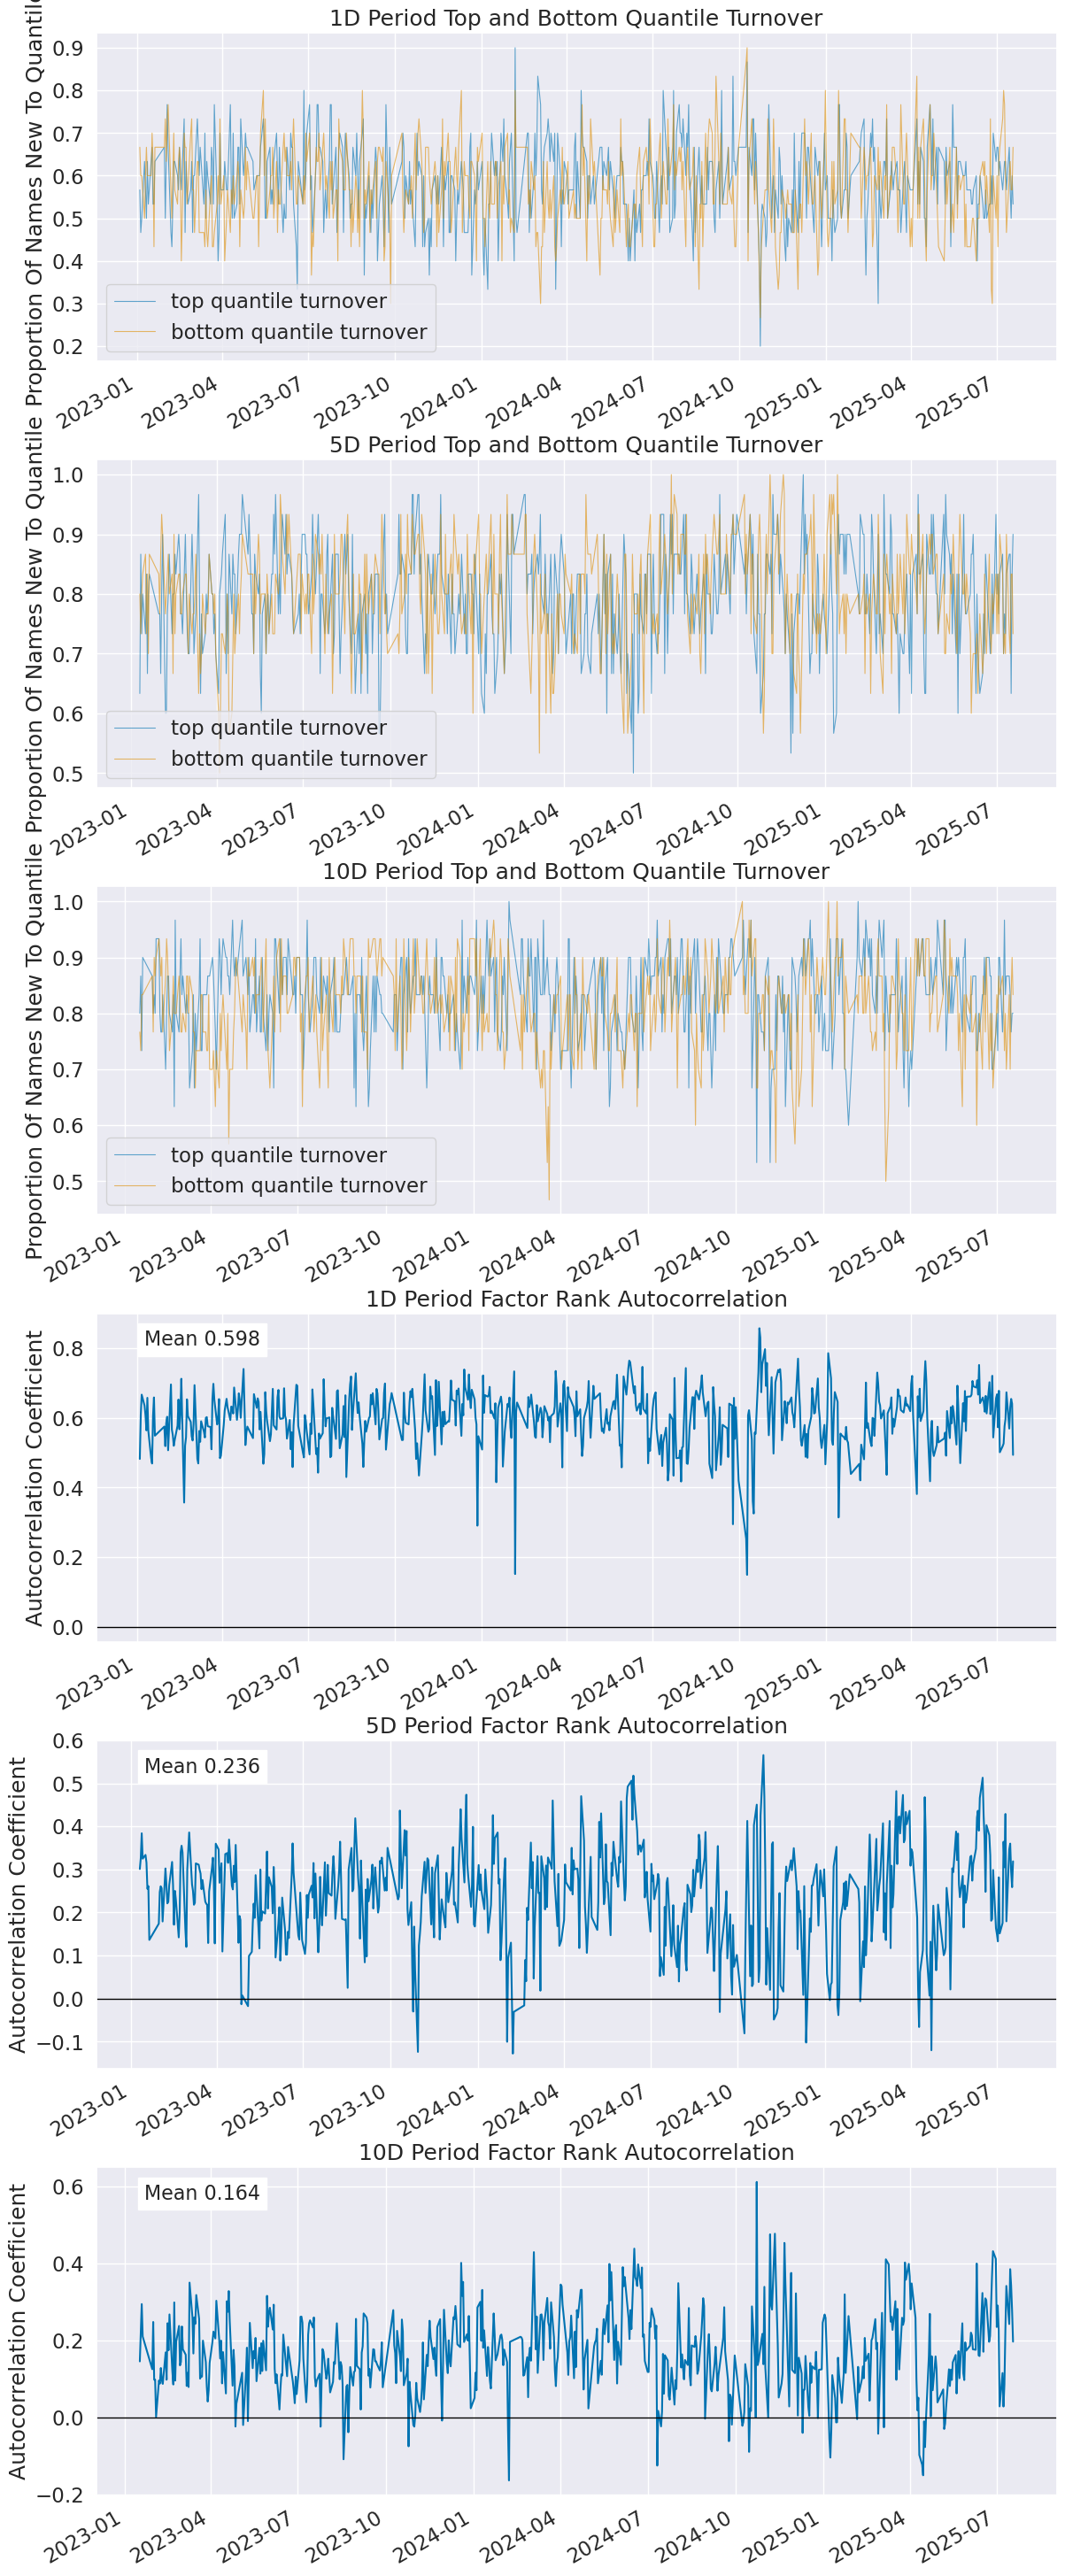

In [48]:
# 检查信号绩效
dataset.show_signal_performance(signal)

In [49]:
# 保存信号数据
lab.save_signal(name, signal)

# 策略回测

In [50]:
# 加载模块
import importlib
from datetime import datetime

from vnpy.alpha.strategy import BacktestingEngine

import vnpy.alpha.strategy.strategies.equity_demo_strategy as equity_demo_strategy

In [51]:
# 重载策略类
importlib.reload(equity_demo_strategy)
EquityDemoStrategy = equity_demo_strategy.EquityDemoStrategy

In [52]:
name='300_mlp_1d'

In [53]:
# 从文件加载信号数据
signal = lab.load_signal(name)

In [54]:
# 创建回测引擎对象
engine = BacktestingEngine(lab)

# 设置回测参数
engine.set_parameters(
    vt_symbols=component_symbols,
    interval=Interval.DAILY,
    start=datetime(2023, 1, 1),
    end=datetime(2025, 8, 1),
    capital=100000000
)

# 添加策略实例
setting = {"top_k": 30, "n_drop": 3, "hold_thresh": 3}
engine.add_strategy(EquityDemoStrategy, setting, signal)

In [55]:
# 执行回测任务
engine.load_data()
engine.run_backtesting()
engine.calculate_result()
engine.calculate_statistics()
engine.show_chart()

2025-10-23 13:52:57 开始加载历史数据


100%|██████████| 591/591 [00:04<00:00, 144.92it/s]

2025-10-23 13:53:01 部分合约历史数据为空：['002450.SZSE', '600005.SSE', '600068.SSE', '600485.SSE', '300104.SZSE', '600074.SSE']
2025-10-23 13:53:01 所有历史数据加载完成
2025-10-23 13:53:01 策略初始化完成
2025-10-23 13:53:01 开始回放历史数据


2025-10-23 13:53:04 历史数据回放结束
2025-10-23 13:53:04 开始计算逐日盯市盈亏
2025-10-23 13:53:04 逐日盯市盈亏计算完成
2025-10-23 13:53:04 开始计算策略统计指标
2025-10-23 13:53:04 ------------------------------
2025-10-23 13:53:04 首个交易日：  2023-01-03
2025-10-23 13:53:04 最后交易日：  2025-08-01
2025-10-23 13:53:04 总交易日：  625
2025-10-23 13:53:04 盈利交易日：  299
2025-10-23 13:53:04 亏损交易日：  325
2025-10-23 13:53:04 起始资金：  100,000,000.00
2025-10-23 13:53:04 结束资金：  128,277,983.54
2025-10-23 13:53:04 总收益率：  28.28%
2025-10-23 13:53:04 年化收益：  10.86%
2025-10-23 13:53:04 最大回撤:   -20,905,582.07
2025-10-23 13:53:04 百分比最大回撤: -19.89%
2025-10-23 13:53:04 最长回撤天数:   381
2025-10-23 13:53:04 总盈亏：  28,277,983.54
2025-10-23 13:53:04 总手续费：  8,637,159.89
2025-10-23 13:53:04 总成交金额：  11,546,649,949.42
2025-10-23 13:53:04 总成交笔数：  3419
2025-10-23 13:53:04 日均盈亏：  45,244.77
2025-10-23 13:53:04 日均手续费：  13,819.46
2025-10-23 13:53:04 日均成交金额：  18,474,639.92
2025-10-23 13:53:04 日均成交笔数：  5.4704
2025-10-23 13:53:04 日均收益率：  0.05%
2025-10-23 13:53:04 收益标准差：  1.04%
2025-10

In [58]:
# 显示超额收益分析结果
engine.show_performance(benchmark_symbol=index_symbol)